In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import matplotlib.pyplot as plt
import numpy as np

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from autoencoder import ConvAutoencoder, NonLinearAutoencoder
from solver import dev_train_vali_all_epochs_conv, test_conv
from rf_computation import compute_rf_for_single_model

import os

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
import seaborn as sns

import torch
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.decomposition import PCA

from tqdm.auto import tqdm

from autoencoder import NonLinearAutoencoder
from solver import *
from model_utils import *

In [2]:
print(torch.cuda.is_available())
device = torch.device(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

True


In [3]:
# MNIST normalisation
transform = transforms.Compose([
    transforms.ToTensor(),  
    transforms.Normalize((0.1307,), (0.3081,))
])

mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_size = int(len(mnist_train) * 0.8)
validation_size = len(mnist_train) - train_size
mnist_train, mnist_val = torch.utils.data.random_split(mnist_train, [train_size, validation_size])

batch_size = 128
train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, num_workers=6)
validation_loader = DataLoader(mnist_val, batch_size=batch_size, shuffle=False, num_workers=6)
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=False, num_workers=6)

In [4]:
test_images = []
test_labels = []

for batch_idx, (data, target) in enumerate(test_loader):
    data = Variable(data)
    test_images.append(data)
    test_labels.append(target)

test_images = np.concatenate(test_images)
test_labels = np.concatenate(test_labels)
test_images = test_images.squeeze(1)

In [5]:
save_path = os.getenv("HOME") + '/paper_cifar_models/mnist/'

In [6]:
def train_sae(save_path):
    sae_model = NonLinearAutoencoder(n_input=784, n_hidden_ls=[64, 32, 16], n_layers=3)
    sae_optimizer = torch.optim.SGD(sae_model.parameters(), lr=0.1, momentum=0.9)

    sae_train_loss, sae_validation_loss = train_vali_all_epochs(
        sae_model, 
        train_loader, 
        validation_loader, 
        sae_optimizer, 
        n_epochs=30, 
        device=torch.device('cuda'), 
        save_path=save_path+'sae/'
        )
    
    return sae_model, sae_train_loss, sae_validation_loss

In [7]:
def train_dae(save_path):
    dae_model = NonLinearAutoencoder(n_input=784, n_hidden_ls=[64, 32, 16], n_layers=3)
    dae_optimizer = torch.optim.SGD(dae_model.parameters(), lr=0.1, momentum=0.9)

    size_ls = [4] * 6 + [6] * 6 + [10] * 8 + [16] * 10

    manner = 'gaussian'

    dae_train_loss, dae_validation_loss = nl_dev_train_vali_all_epochs(
        dae_model, 
        size_ls,
        manner,
        train_loader,
        validation_loader, 
        dae_optimizer, 
        n_epochs=30,
        device=torch.device('cpu'), 
        save_path=save_path+'dae/'
        )
    
    return dae_model, dae_train_loss, dae_validation_loss

In [18]:
sae_model = train_sae(save_path)

Train Epoch: 0 [47872/48000 (100%)]	Loss: 0.004698: 100%|██████████| 375/375 [00:02<00:00, 166.47it/s]


====> Epoch: 0 Average loss: 0.7075


/home/david/Documents/UNI_LOCAL/developing-autoencoders/solver.py:535: UserWarning: volatile was removed and now has no effect. Use `with torch.no_grad():` instead.
  data = Variable(data, volatile=True).to(device)


====> Test set loss: 0.6011
Weights saved.


Train Epoch: 1 [47872/48000 (100%)]	Loss: 0.003784: 100%|██████████| 375/375 [00:02<00:00, 168.16it/s]

...

====> Epoch: 28 Average loss: 0.2724


====> Test set loss: 0.2708
Weights saved.


Train Epoch: 29 [47872/48000 (100%)]	Loss: 0.002084: 100%|██████████| 375/375 [00:02<00:00, 144.66it/s]

====> Epoch: 29 Average loss: 0.2683


====> Test set loss: 0.2671
Weights saved.
All train losses saved.


In [10]:
dae_model = train_dae(save_path)

[ 4  4  4  4  4  4  6  6  6  6  6  6 10 10 10 10 10 10 10 10 16 16 16 16
 16 16 16 16 16 16]
4


Train Epoch: 0 [47872/48000 (100%)]	Loss: 0.004822: 100%|██████████| 375/375 [00:02<00:00, 139.51it/s]

====> Epoch: 0 Average loss: 0.7162



/home/david/Documents/UNI_LOCAL/developing-autoencoders/solver.py:535: UserWarning: volatile was removed and now has no effect. Use `with torch.no_grad():` instead.
  data = Variable(data, volatile=True).to(device)


====> Test set loss: 0.6166
Weights saved.
4


...

Train Epoch: 28 [47872/48000 (100%)]	Loss: 0.002107: 100%|██████████| 375/375 [00:02<00:00, 172.75it/s]


====> Epoch: 28 Average loss: 0.2645
====> Test set loss: 0.2631
Weights saved.
16


Train Epoch: 29 [47872/48000 (100%)]	Loss: 0.002178: 100%|██████████| 375/375 [00:02<00:00, 170.04it/s]

====> Epoch: 29 Average loss: 0.2606


====> Test set loss: 0.2611
Weights saved.
All train losses saved.


In [8]:
save_path_pca = os.getenv("HOME") + '/paper_cifar_models/mnist_pca_init/'

In [10]:
sae_model_pca_init = NonLinearAutoencoder(n_input=784, n_hidden_ls=[64, 32, 16], n_layers=3)
sae_optimizer = torch.optim.SGD(sae_model_pca_init.parameters(), lr=0.1, momentum=0.9)

# Compute PCA for different dimensions based on hidden layer sizes
hidden_sizes = [64, 32, 16]
pcas = {}

# Fit PCA for each hidden layer size
for size in hidden_sizes:
    pca = PCA(n_components=size)
    pca.fit(test_images.reshape(test_images.shape[0], -1)) #TODO: train_images
    pcas[size] = pca

with torch.no_grad():
    encoder_modules = dict(sae_model_pca_init.encoder.named_modules())
    decoder_modules = dict(sae_model_pca_init.decoder.named_modules())
    
    # Initialize all encoder layers
    for i in range(1, sae_model_pca_init.n_layers + 1):
        encoder_layer = encoder_modules[f'encoder_{i}']
        
        if i == 1:
            # First encoder layer: 784 -> 64
            pca_components = pcas[64].components_  # 64 x 784
            encoder_layer.weight[:64].copy_(torch.from_numpy(pca_components))
        elif i == 2:
            # Second encoder layer: 64 -> 32
            pca_components = pcas[32].components_  # 32 x 784, but we need 32 x 64
            # Use first 32 components, truncated to 64 dimensions
            encoder_layer.weight[:32, :32].copy_(torch.from_numpy(pca_components[:32, :32]))
        elif i == 3:
            # Third encoder layer: 32 -> 16
            pca_components = pcas[16].components_  # 16 x 784, but we need 16 x 32
            # Use first 16 components, truncated to 32 dimensions
            encoder_layer.weight[:16, :16].copy_(torch.from_numpy(pca_components[:16, :16]))
        
        encoder_layer.bias.zero_()
    
    # Initialize all decoder layers (reverse order)
    for i in range(1, sae_model_pca_init.n_layers + 1):
        decoder_layer = decoder_modules[f'decoder_{i}']
        
        if i == 1:
            # First decoder layer: 16 -> 32
            # Use transpose of encoder layer 3 weights
            encoder_3 = encoder_modules['encoder_3']
            decoder_layer.weight[:32, :16].copy_(encoder_3.weight[:16, :32].T)
        elif i == 2:
            # Second decoder layer: 32 -> 64
            # Use transpose of encoder layer 2 weights
            encoder_2 = encoder_modules['encoder_2']
            decoder_layer.weight[:64, :32].copy_(encoder_2.weight[:32, :64].T)
        elif i == 3:
            # Third decoder layer: 64 -> 784 (output layer)
            # Use transpose of encoder layer 1 weights
            encoder_1 = encoder_modules['encoder_1']
            decoder_layer.weight[:784, :64].copy_(encoder_1.weight[:64, :784].T)
        
        decoder_layer.bias.zero_()

print("PCA initialization completed for all hidden layers!")
print("Architecture: 784 -> 64 -> 32 -> 16 -> 32 -> 64 -> 784")
print("Encoder layers initialized:", [f"encoder_{i}" for i in range(1, sae_model_pca_init.n_layers + 1)])
print("Decoder layers initialized:", [f"decoder_{i}" for i in range(1, sae_model_pca_init.n_layers + 1)])

PCA initialization completed for all hidden layers!
Architecture: 784 -> 64 -> 32 -> 16 -> 32 -> 64 -> 784
Encoder layers initialized: ['encoder_1', 'encoder_2', 'encoder_3']
Decoder layers initialized: ['decoder_1', 'decoder_2', 'decoder_3']


In [11]:
sae_train_loss_pca, sae_validation_loss_pca = train_vali_all_epochs(
    sae_model_pca_init, 
    train_loader, 
    validation_loader, 
    sae_optimizer, 
    n_epochs=30, 
    device=torch.device('cuda'), 
    save_path=save_path_pca+'sae/'
    )

Train Epoch: 0 [47872/48000 (100%)]	Loss: 0.004644: 100%|██████████| 375/375 [00:02<00:00, 135.68it/s]
Train Epoch: 0 [47872/48000 (100%)]	Loss: 0.004644: 100%|██████████| 375/375 [00:02<00:00, 135.68it/s]


====> Epoch: 0 Average loss: 0.6993


/home/david/Documents/UNI_LOCAL/developing-autoencoders/solver.py:532: UserWarning: volatile was removed and now has no effect. Use `with torch.no_grad():` instead.
  data = Variable(data, volatile=True).to(device)


====> Test set loss: 0.6110
Directory created: /home/david/paper_cifar_models/mnist_pca_init/sae/
Weights saved.


Train Epoch: 1 [47872/48000 (100%)]	Loss: 0.003918: 100%|██████████| 375/375 [00:02<00:00, 174.69it/s]
Train Epoch: 1 [47872/48000 (100%)]	Loss: 0.003918: 100%|██████████| 375/375 [00:02<00:00, 174.69it/s]


...

====> Epoch: 28 Average loss: 0.2295


====> Test set loss: 0.2318
Weights saved.


Train Epoch: 29 [47872/48000 (100%)]	Loss: 0.001879: 100%|██████████| 375/375 [00:02<00:00, 168.72it/s]

====> Epoch: 29 Average loss: 0.2284


====> Test set loss: 0.2315
Weights saved.
All train losses saved.


In [15]:
dae_model_pca_init = NonLinearAutoencoder(n_input=784, n_hidden_ls=[64, 32, 16], n_layers=3)
dae_optimizer = torch.optim.SGD(dae_model_pca_init.parameters(), lr=0.1, momentum=0.9)

# Compute PCA for different dimensions based on hidden layer sizes
hidden_sizes = [64, 32, 16]
pcas = {}

# Fit PCA for each hidden layer size
for size in hidden_sizes:
    pca = PCA(n_components=size)
    pca.fit(test_images.reshape(test_images.shape[0], -1))
    pcas[size] = pca

with torch.no_grad():
    encoder_modules = dict(dae_model_pca_init.encoder.named_modules())
    decoder_modules = dict(dae_model_pca_init.decoder.named_modules())
    
    # Initialize all encoder layers
    for i in range(1, dae_model_pca_init.n_layers + 1):
        encoder_layer = encoder_modules[f'encoder_{i}']
        
        if i == 1:
            # First encoder layer: 784 -> 64
            pca_components = pcas[64].components_  # 64 x 784
            encoder_layer.weight[:64].copy_(torch.from_numpy(pca_components))
        elif i == 2:
            # Second encoder layer: 64 -> 32
            pca_components = pcas[32].components_  # 32 x 784, but we need 32 x 64
            # Use first 32 components, truncated to 64 dimensions
            encoder_layer.weight[:32, :32].copy_(torch.from_numpy(pca_components[:32, :32]))
        elif i == 3:
            # Third encoder layer: 32 -> 16
            pca_components = pcas[16].components_  # 16 x 784, but we need 16 x 32
            # Use first 16 components, truncated to 32 dimensions
            encoder_layer.weight[:16, :16].copy_(torch.from_numpy(pca_components[:16, :16]))
        
        encoder_layer.bias.zero_()
    
    # Initialize all decoder layers (reverse order)
    for i in range(1, dae_model_pca_init.n_layers + 1):
        decoder_layer = decoder_modules[f'decoder_{i}']
        
        if i == 1:
            # First decoder layer: 16 -> 32
            # Use transpose of encoder layer 3 weights
            encoder_3 = encoder_modules['encoder_3']
            decoder_layer.weight[:32, :16].copy_(encoder_3.weight[:16, :32].T)
        elif i == 2:
            # Second decoder layer: 32 -> 64
            # Use transpose of encoder layer 2 weights
            encoder_2 = encoder_modules['encoder_2']
            decoder_layer.weight[:64, :32].copy_(encoder_2.weight[:32, :64].T)
        elif i == 3:
            # Third decoder layer: 64 -> 784 (output layer)
            # Use transpose of encoder layer 1 weights
            encoder_1 = encoder_modules['encoder_1']
            decoder_layer.weight[:784, :64].copy_(encoder_1.weight[:64, :784].T)
        
        decoder_layer.bias.zero_()

print("PCA initialization completed for all hidden layers!")
print("Architecture: 784 -> 64 -> 32 -> 16 -> 32 -> 64 -> 784")
print("Encoder layers initialized:", [f"encoder_{i}" for i in range(1, dae_model_pca_init.n_layers + 1)])
print("Decoder layers initialized:", [f"decoder_{i}" for i in range(1, dae_model_pca_init.n_layers + 1)])

PCA initialization completed for all hidden layers!
Architecture: 784 -> 64 -> 32 -> 16 -> 32 -> 64 -> 784
Encoder layers initialized: ['encoder_1', 'encoder_2', 'encoder_3']
Decoder layers initialized: ['decoder_1', 'decoder_2', 'decoder_3']


In [16]:
size_ls = [4] * 6 + [6] * 6 + [10] * 8 + [16] * 10

manner = 'gaussian'

dae_train_loss_pca, dae_validation_loss_pca = nl_dev_train_vali_all_epochs(
    dae_model_pca_init, 
    size_ls,
    manner,
    train_loader,
    validation_loader, 
    dae_optimizer, 
    n_epochs=30,
    device=torch.device('cpu'), 
    save_path=save_path_pca+'dae/'
    )

Directory created: /home/david/paper_cifar_models/mnist_pca_init/dae/
[ 4  4  4  4  4  4  6  6  6  6  6  6 10 10 10 10 10 10 10 10 16 16 16 16
 16 16 16 16 16 16]
4


Train Epoch: 0 [47872/48000 (100%)]	Loss: 0.004837: 100%|██████████| 375/375 [00:02<00:00, 125.52it/s]

====> Epoch: 0 Average loss: 0.7103



/home/david/Documents/UNI_LOCAL/developing-autoencoders/solver.py:532: UserWarning: volatile was removed and now has no effect. Use `with torch.no_grad():` instead.
  data = Variable(data, volatile=True).to(device)
/home/david/Documents/UNI_LOCAL/developing-autoencoders/solver.py:532: UserWarning: volatile was removed and now has no effect. Use `with torch.no_grad():` instead.
  data = Variable(data, volatile=True).to(device)


====> Test set loss: 0.6168
Weights saved.
4


...

====> Test set loss: 0.2914
Weights saved.
16


Train Epoch: 28 [47872/48000 (100%)]	Loss: 0.002118: 100%|██████████| 375/375 [00:02<00:00, 142.11it/s]
Train Epoch: 28 [47872/48000 (100%)]	Loss: 0.002118: 100%|██████████| 375/375 [00:02<00:00, 142.11it/s]


====> Epoch: 28 Average loss: 0.2871
====> Test set loss: 0.2926
Weights saved.
16
====> Test set loss: 0.2926
Weights saved.
16


Train Epoch: 29 [47872/48000 (100%)]	Loss: 0.002248: 100%|██████████| 375/375 [00:02<00:00, 127.84it/s]
Train Epoch: 29 [47872/48000 (100%)]	Loss: 0.002248: 100%|██████████| 375/375 [00:02<00:00, 127.84it/s]


====> Epoch: 29 Average loss: 0.2846
====> Test set loss: 0.2880
Weights saved.
All train losses saved.
====> Test set loss: 0.2880
Weights saved.
All train losses saved.


In [24]:
sae_train_loss = np.load(os.getenv("HOME") + '/paper_cifar_models/mnist/sae/all_train_losses.npy')
dae_train_loss = np.load(os.getenv("HOME") + '/paper_cifar_models/mnist/dae/all_train_losses.npy')

In [25]:
# get the final epoch of all train losses
sae_train_loss_final = sae_train_loss[-1]

In [26]:
sae_train_loss_final

array([0.22702828, 0.22466987, 0.23379473, 0.21689886, 0.22515456,
       0.21790518, 0.20062956, 0.20632225, 0.22373042, 0.22138967,
       0.22829266, 0.22420546, 0.24374774, 0.23150934, 0.21822158,
       0.23013224, 0.22028245, 0.20468657, 0.23054372, 0.22405516,
       0.22875057, 0.22113691, 0.22050165, 0.21268794, 0.22345442,
       0.22506826, 0.21258922, 0.22022107, 0.23733842, 0.22195372,
       0.23675619, 0.21614465, 0.21542075, 0.21317583, 0.22531715,
       0.22294924, 0.20846379, 0.2310961 , 0.21659733, 0.23167975,
       0.21759735, 0.21881095, 0.22354358, 0.22624984, 0.23466142,
       0.22101809, 0.21845192, 0.22352792, 0.21678215, 0.22262338,
       0.21624482, 0.22954281, 0.20138557, 0.24397534, 0.22533736,
       0.22854897, 0.21158466, 0.22978027, 0.22653827, 0.21932736,
       0.21417612, 0.20301791, 0.22306122, 0.22076735, 0.20905186,
       0.21778415, 0.21243788, 0.22918187, 0.22454219, 0.21787263,
       0.22548391, 0.22452085, 0.20631345, 0.22871424, 0.22601

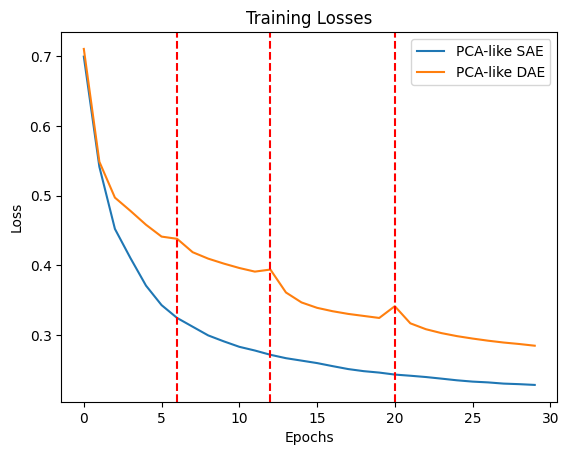

In [21]:
# plt.plot(sae_train_loss, label='SAE')
# plt.plot(dae_train_loss, label='DAE')
plt.plot(sae_train_loss_pca, label='PCA-like SAE')
plt.plot(dae_train_loss_pca, label='PCA-like DAE')
plt.legend()
plt.axvline(x=6, color='r', linestyle='--')
plt.axvline(x=12, color='r', linestyle='--')
plt.axvline(x=20, color='r', linestyle='--')
plt.title('Training Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()